In [2]:
import sympy as sp
import control as ct
import pandas as pd
import matplotlib.pyplot as plt
from mason.solver import MasonSolver,MIMOSFGSolver
from mason.adapters.control import *
s = sp.symbols("s")
df = pd.read_csv("../mason/tikz/data.csv")
solver = MIMOSFGSolver(entry_solver_cls=MasonSolver)

In [7]:
G11, G12, G21, G22 = sp.symbols("G11 G12 G21 G22")

data = {
    "edges": [
        ("R1", "C1", "G11"),
        ("R1", "C2", "G12"),
        ("R2", "C1", "G21"),
        ("R2", "C2", "G22"),
    ],
    "sources": ["R1", "R2"],
    "sinks": ["C1", "C2"],
}

solver.load_from_dict(data)

subs_dict = {
    G11: 1/(s+1),
    G12: 2/(s+2),
    G21: 3/(s+3),
    G22: 4/(s+4),
}


Gsym,info = solver.transfer_matrix(
    sources=data["sources"],
    sinks=data["sinks"]
)
Gsym

Matrix([
[G11, G21],
[G12, G22]])

In [8]:

G_sub = Gsym.subs(subs_dict) # type: ignore
#display(G_sub)

In [9]:
G_sub

Matrix([
[1/(s + 1), 3/(s + 3)],
[2/(s + 2), 4/(s + 4)]])

In [11]:
data = {
    "edges": [
        (row.start, row.end, row.gain)
        for _, row in df.iterrows()
    ],
    "sources": ["R1", "R2", "D"],
    "sinks": ["C1", "C2"],
}

solver.load_from_dict(data)

Gsym,info = solver.transfer_matrix(
    sources=data["sources"],
    sinks=data["sinks"],
)

display(Gsym)

Matrix([
[G1*(G2*a22 + 1)/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1),      -G1*G2*a21/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1),      -G1*G2*a21*sigma/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1)],
[     -G1*G2*a12/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1), G2*(G1*a11 + 1)/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1), G2*sigma*(G1*a11 + 1)/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1)]])

In [12]:
G_u,info = solver.transfer_matrix(
    sources=["R1", "R2"],
    sinks=["C1", "C2"],
)
display(G_u)

Matrix([
[G1*(G2*a22 + 1)/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1),      -G1*G2*a21/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1)],
[     -G1*G2*a12/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1), G2*(G1*a11 + 1)/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1)]])

In [13]:
G_d,info = solver.transfer_matrix(
    sources=["D"],
    sinks=["C1", "C2"],

)
display(G_d)

Matrix([
[     -G1*G2*a21*sigma/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1)],
[G2*sigma*(G1*a11 + 1)/(G1*G2*a11*a22 - G1*G2*a12*a21 + G1*a11 + G2*a22 + 1)]])

In [14]:
all_syms = set()
for i in range(G_sub.shape[0]):
    for j in range(G_sub.shape[1]):
        all_syms |= G_sub[i, j].free_symbols

print(all_syms)

{s}


In [15]:
G11 = expr_to_tf(G_sub[0, 0], s)
print(G11)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    1
  -----
  s + 1


In [16]:
print(ct.poles(G11))
print(ct.zeros(G11))

[-1.+0.j]
[]


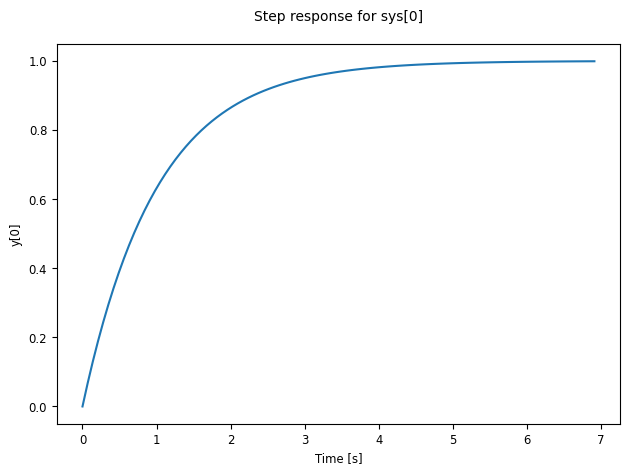

In [17]:
ct.step_response(G11).plot()

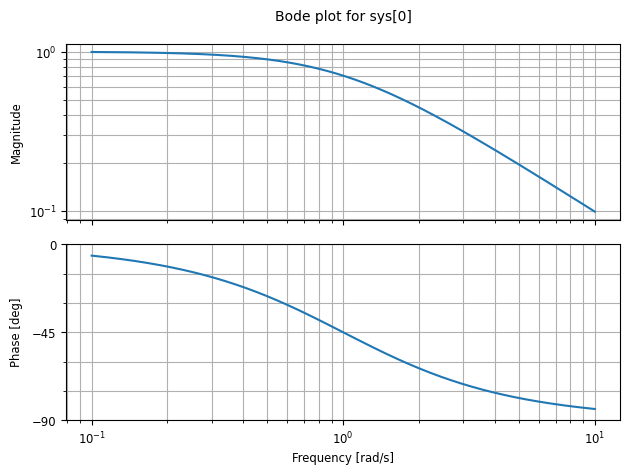

In [18]:
ct.bode_plot(G11)

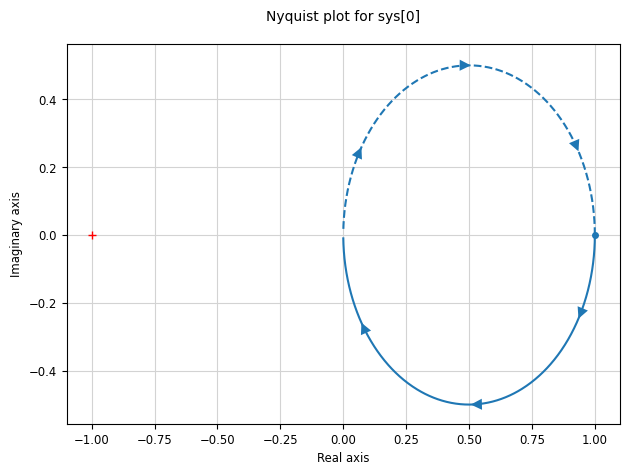

In [19]:
ct.nyquist_plot(G11)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


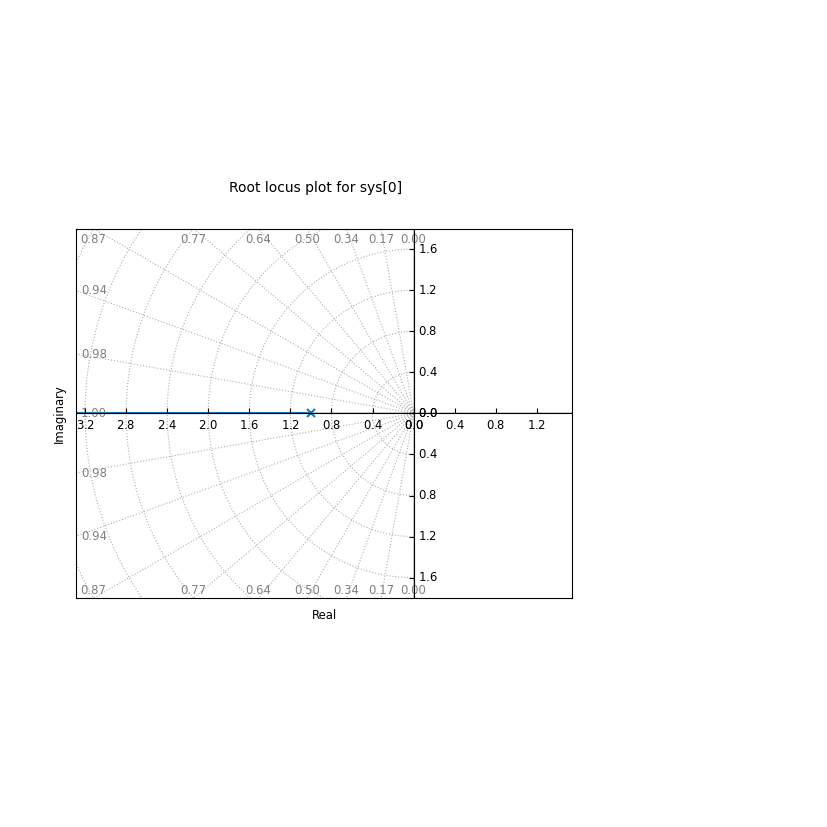

In [20]:
ct.root_locus_plot(G11)

In [22]:
G_ss = matrix_to_control_ss(G_sub, s, minimal=False)
print("\nStateSpace:")
print(G_ss)


StateSpace:
<StateSpace>: sys[14]
Inputs (2): ['u[0]', 'u[1]']
Outputs (2): ['y[0]', 'y[1]']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[-3.00000000e+00 -8.94369607e-16  3.40695718e-16 -2.00000000e+00]
     [-1.22072437e-16 -7.00000000e+00 -1.20000000e+00  1.36732406e-15]
     [ 9.99200722e-16  1.00000000e+01 -8.57738080e-16 -1.37083831e-15]
     [ 1.00000000e+00  0.00000000e+00 -3.36707569e-16  2.19078044e-16]]

B = [[ 1.00000000e+00 -1.11022302e-16]
     [ 0.00000000e+00 -1.00000000e+00]
     [ 0.00000000e+00  0.00000000e+00]
     [ 0.00000000e+00  0.00000000e+00]]

C = [[ 1.  -3.  -1.2  2. ]
     [ 2.  -4.  -1.2  2. ]]

D = [[0. 0.]
     [0. 0.]]
